# DeepLabV3 + MobileNetV3 - Semantic Segmentation Training
## Custom HVAC Equipment Segmentation

Este notebook entrena un modelo de segmentación semántica para equipos HVAC:
- **Arquitectura:** DeepLabV3 con backbone MobileNetV3-Large
- **Tarea:** Segmentación semántica pixel-wise
- **Dataset:** Roboflow con máscaras de segmentación
- **Output:** Backbone entrenado + visualización de mapas de atención

### Pipeline:
1. Descargar dataset de Roboflow (formato: Semantic Segmentation Masks)
2. Entrenar DeepLabV3 con tus clases personalizadas
3. Extraer backbone entrenado
4. Comparar mapas de atención: COCO pre-entrenado vs Tu backbone entrenado

### Clases de ejemplo para HVAC:
- Background (0)
- Compresor (1)
- Intercambiador de calor (2)
- Ventilador (3)
- Panel eléctrico (4)
- Tuberías (5)

## 1. Instalación de Dependencias

In [8]:
!pip install pycocotools

## 2. Descargar Dataset de Roboflow

### IMPORTANTE: Formato del Dataset

En Roboflow, exporta tu dataset en uno de estos formatos:

**Opción 1: Semantic Segmentation Masks (RECOMENDADO)**
- Estructura:
  ```
  dataset/
    train/
      images/
        img001.jpg
        img002.jpg
      masks/
        img001.png  (cada píxel = clase ID)
        img002.png
    valid/
      images/
      masks/
  ```

**Opción 2: PNG Mask Semantic (alternativa)**
- Similar estructura, máscaras en PNG

### Configuración en tu código de Roboflow:
Cambia estos valores según tu proyecto:

In [22]:
from roboflow import Roboflow
import os

# ============================================
# CONFIGURA ESTOS VALORES CON TU PROYECTO
# ============================================
ROBOFLOW_API_KEY = "LHiJvoAFmvmbSi50SwC1"  # Obtén de: https://app.roboflow.com/settings/api
WORKSPACE_NAME = "hvac-whaik"       # Tu workspace en Roboflow
PROJECT_NAME = "hvac-segmentation-automatic-flow"    # Tu proyecto de segmentación
VERSION_NUMBER = 5                    # Versión del dataset

# Formato del dataset (elige uno):
# - "png-mask-semantic" para máscaras PNG
# - "coco-segmentation" para formato COCO
DATASET_FORMAT = "coco-segmentation"
# ============================================

print("Descargando dataset de Roboflow...")
print(f"Workspace: {WORKSPACE_NAME}")
print(f"Proyecto: {PROJECT_NAME}")
print(f"Versión: {VERSION_NUMBER}")
print(f"Formato: {DATASET_FORMAT}")
print("-" * 60)

# Inicializar Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(WORKSPACE_NAME).project(PROJECT_NAME)
version = project.version(VERSION_NUMBER)

# Descargar dataset
dataset = version.download(DATASET_FORMAT)

print(f"\n✓ Dataset descargado en: {dataset.location}")
print(f"✓ Ruta absoluta: {os.path.abspath(dataset.location)}")

# Verificar estructura
if os.path.exists(dataset.location):
    print("\nContenido del dataset:")
    for item in os.listdir(dataset.location):
        full_path = os.path.join(dataset.location, item)
        if os.path.isdir(full_path):
            num_items = len(os.listdir(full_path))
            print(f"  📁 {item}/: {num_items} items")
        else:
            print(f"  📄 {item}")

Descargando dataset de Roboflow...
Workspace: hvac-whaik
Proyecto: hvac-segmentation-automatic-flow
Versión: 5
Formato: coco-segmentation
------------------------------------------------------------
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to hvac-segmentation-automatic-flow-5 in coco-segmentation:: 100%|██████████| 4977/4977 [00:00<00:00, 12927.68it/s]



✓ Dataset descargado en: /workspace/notebooks/hvac-segmentation-automatic-flow-5
✓ Ruta absoluta: /workspace/notebooks/hvac-segmentation-automatic-flow-5

Contenido del dataset:
  📁 valid/: 132 items
  📁 test/: 70 items
  📁 train/: 4771 items
  📄 README.roboflow.txt


## 3. Importar Librerías y Configuración

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
import json
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Configuración de dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

# Optimizaciones
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print("\n✓ Librerías importadas correctamente!")

Usando dispositivo: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU
CUDA Version: 12.8

✓ Librerías importadas correctamente!


## 4. Análisis del Dataset

Examina las clases y estructura de tu dataset de segmentación.

In [2]:
# Definir ruta del dataset (ajusta según tu descarga)
#DATASET_PATH = Path(dataset.location)
DATASET_PATH = Path("./hvac-segmentation-automatic-flow-5")

# ============================================
# CONFIGURA TUS CLASES AQUÍ
# ============================================
# Clases del dataset HVAC de Roboflow:
CLASS_NAMES = [
    "HVAC-TE7b-xd4I-nNKl-f9NC-HV-x8J2",  # 0 (parent/background)
    "GRAVITY-VENT",                       # 1
    "REFRIGERATOR",                       # 2
    "RESIDENTIAL-UNIT",                   # 3
    "RTU",                                # 4
    "SPLIT-SYSTEM",                       # 5
    "VRF-SYSTEM",                         # 6
    "WINDOW-UNIT",                        # 7
]

# Paleta de colores para visualización (RGB)
COLOR_PALETTE = [
    [0, 0, 0],         # 0: HVAC (parent) - negro
    [255, 0, 0],       # 1: GRAVITY-VENT - rojo
    [128, 128, 128],   # 2: OTHER - gris
    [0, 255, 255],     # 3: REFRIGERATOR - cian
    [255, 128, 0],     # 4: RESIDENTIAL-UNIT - naranja
    [128, 0, 255],     # 5: RTU - púrpura
    [0, 255, 0],       # 6: SPLIT-SYSTEM - verde
    [255, 0, 255],     # 7: VRF-SYSTEM - magenta
    [255, 255, 0],     # 8: WINDOW-UNIT - amarillo
    [0, 128, 255],     # 9: coil - azul claro
    [0, 0, 255],       # 10: fan - azul
    [255, 192, 203],   # 11: logo - rosa
    [128, 255, 0]      # 12: vent - verde lima
]

NUM_CLASSES = len(CLASS_NAMES)
# ============================================

print("=" * 70)
print("CONFIGURACIÓN DEL DATASET DE SEGMENTACIÓN")
print("=" * 70)
print(f"Número de clases: {NUM_CLASSES}")
print(f"\nClases:")
for idx, name in enumerate(CLASS_NAMES):
    color = COLOR_PALETTE[idx]
    print(f"  [{idx}] {name:20s} - RGB{tuple(color)}")

# Contar imágenes
train_images = list((DATASET_PATH / "train" / "images").glob("*.*")) if (DATASET_PATH / "train" / "images").exists() else list((DATASET_PATH / "train").glob("*.jpg"))
valid_images = list((DATASET_PATH / "valid" / "images").glob("*.*")) if (DATASET_PATH / "valid" / "images").exists() else list((DATASET_PATH / "valid").glob("*.jpg"))

print(f"\nImágenes de entrenamiento: {len(train_images)}")
print(f"Imágenes de validación: {len(valid_images)}")
print("=" * 70)

CONFIGURACIÓN DEL DATASET DE SEGMENTACIÓN
Número de clases: 8

Clases:
  [0] HVAC-TE7b-xd4I-nNKl-f9NC-HV-x8J2 - RGB(0, 0, 0)
  [1] GRAVITY-VENT         - RGB(255, 0, 0)
  [2] REFRIGERATOR         - RGB(128, 128, 128)
  [3] RESIDENTIAL-UNIT     - RGB(0, 255, 255)
  [4] RTU                  - RGB(255, 128, 0)
  [5] SPLIT-SYSTEM         - RGB(128, 0, 255)
  [6] VRF-SYSTEM           - RGB(0, 255, 0)
  [7] WINDOW-UNIT          - RGB(255, 0, 255)

Imágenes de entrenamiento: 4770
Imágenes de validación: 131


## 5. Dataset Personalizado para Segmentación

In [26]:
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

class SegmentationDataset(Dataset):
    """
    Dataset para segmentación semántica COCO
    Lee anotaciones desde _annotations.coco.json
    """
    def __init__(self, root_dir, split='train', img_size=224, num_classes=8):
        """
        Args:
            root_dir: Directorio raíz del dataset
            split: 'train' o 'valid'
            img_size: Tamaño para redimensionar imágenes
            num_classes: Número de clases
        """
        self.root_dir = Path(root_dir)
        self.split = split
        self.img_size = img_size
        self.num_classes = num_classes
        
        # Ruta al archivo COCO JSON
        split_dir = self.root_dir / split
        coco_json_path = split_dir / "_annotations.coco.json"
        
        if not coco_json_path.exists():
            raise FileNotFoundError(f"No se encontró {coco_json_path}")
        
        # Cargar anotaciones COCO
        print(f"Cargando anotaciones COCO desde {coco_json_path}...")
        self.coco = COCO(str(coco_json_path))
        
        # Obtener IDs de imágenes
        self.image_ids = list(self.coco.imgs.keys())
        
        # Directorio de imágenes
        self.images_dir = split_dir
        
        # Transformaciones para imágenes
        self.img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])
        
        print(f"✓ {len(self.image_ids)} imágenes cargadas con anotaciones COCO")
    
    def __len__(self):
        return len(self.image_ids)
    
    def _create_mask_from_coco(self, img_id, height, width):
        """Crea una máscara de segmentación desde anotaciones COCO"""
        # Obtener todas las anotaciones para esta imagen
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        
        # Crear máscara vacía
        mask = np.zeros((height, width), dtype=np.uint8)
        
        # Dibujar cada anotación en la máscara
        for ann in anns:
            category_id = ann['category_id']
            
            # Convertir segmentación a máscara binaria
            if 'segmentation' in ann:
                if isinstance(ann['segmentation'], list):
                    # Polígono
                    from PIL import ImageDraw
                    temp_mask = Image.new('L', (width, height), 0)
                    draw = ImageDraw.Draw(temp_mask)
                    
                    for seg in ann['segmentation']:
                        # Convertir lista plana a lista de tuplas (x, y)
                        poly = [(seg[i], seg[i+1]) for i in range(0, len(seg), 2)]
                        draw.polygon(poly, outline=1, fill=1)
                    
                    temp_mask_np = np.array(temp_mask)
                    # Asignar el category_id donde la máscara es 1
                    mask[temp_mask_np == 1] = category_id
                    
                elif isinstance(ann['segmentation'], dict):
                    # RLE (Run Length Encoding)
                    rle = ann['segmentation']
                    temp_mask = coco_mask.decode(rle)
                    mask[temp_mask == 1] = category_id
        
        return mask
    
    def __getitem__(self, idx):
        # Obtener información de la imagen
        img_id = self.image_ids[idx]
        img_info = self.coco.imgs[img_id]
        img_filename = img_info['file_name']
        
        # Cargar imagen
        img_path = self.images_dir / img_filename
        img = Image.open(img_path).convert('RGB')
        original_width, original_height = img.size
        
        # Crear máscara desde anotaciones COCO
        mask = self._create_mask_from_coco(img_id, original_height, original_width)
        
        # Redimensionar máscara (usando NEAREST para mantener índices de clase)
        mask = Image.fromarray(mask)
        mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)
        mask = np.array(mask, dtype=np.int64)
        
        # Asegurar que los valores están en rango válido
        mask = np.clip(mask, 0, self.num_classes - 1)
        
        # Aplicar transformaciones a la imagen
        img = self.img_transform(img)
        mask = torch.from_numpy(mask).long()
        
        return img, mask

print("✓ Clase SegmentationDataset creada (compatible con COCO JSON)!")

✓ Clase SegmentationDataset creada (compatible con COCO JSON)!


## 6. Crear DataLoaders

In [27]:
# Configuración de entrenamiento
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 0

# Crear datasets
train_dataset = SegmentationDataset(
    root_dir=DATASET_PATH,
    split='train',
    img_size=IMG_SIZE,
    num_classes=NUM_CLASSES
)

valid_dataset = SegmentationDataset(
    root_dir=DATASET_PATH,
    split='valid',
    img_size=IMG_SIZE,
    num_classes=NUM_CLASSES
)

# Crear dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"✓ Dataset de entrenamiento: {len(train_dataset)} imágenes")
print(f"✓ Dataset de validación: {len(valid_dataset)} imágenes")
print(f"✓ Batches de entrenamiento: {len(train_loader)}")
print(f"✓ Batches de validación: {len(valid_loader)}")

Cargando anotaciones COCO desde hvac-segmentation-automatic-flow-5/train/_annotations.coco.json...
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
✓ 4770 imágenes cargadas con anotaciones COCO
Cargando anotaciones COCO desde hvac-segmentation-automatic-flow-5/valid/_annotations.coco.json...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
✓ 131 imágenes cargadas con anotaciones COCO
✓ Dataset de entrenamiento: 4770 imágenes
✓ Dataset de validación: 131 imágenes
✓ Batches de entrenamiento: 299
✓ Batches de validación: 9


## 7. Visualizar Muestras del Dataset

Visualizando muestras del dataset de entrenamiento:


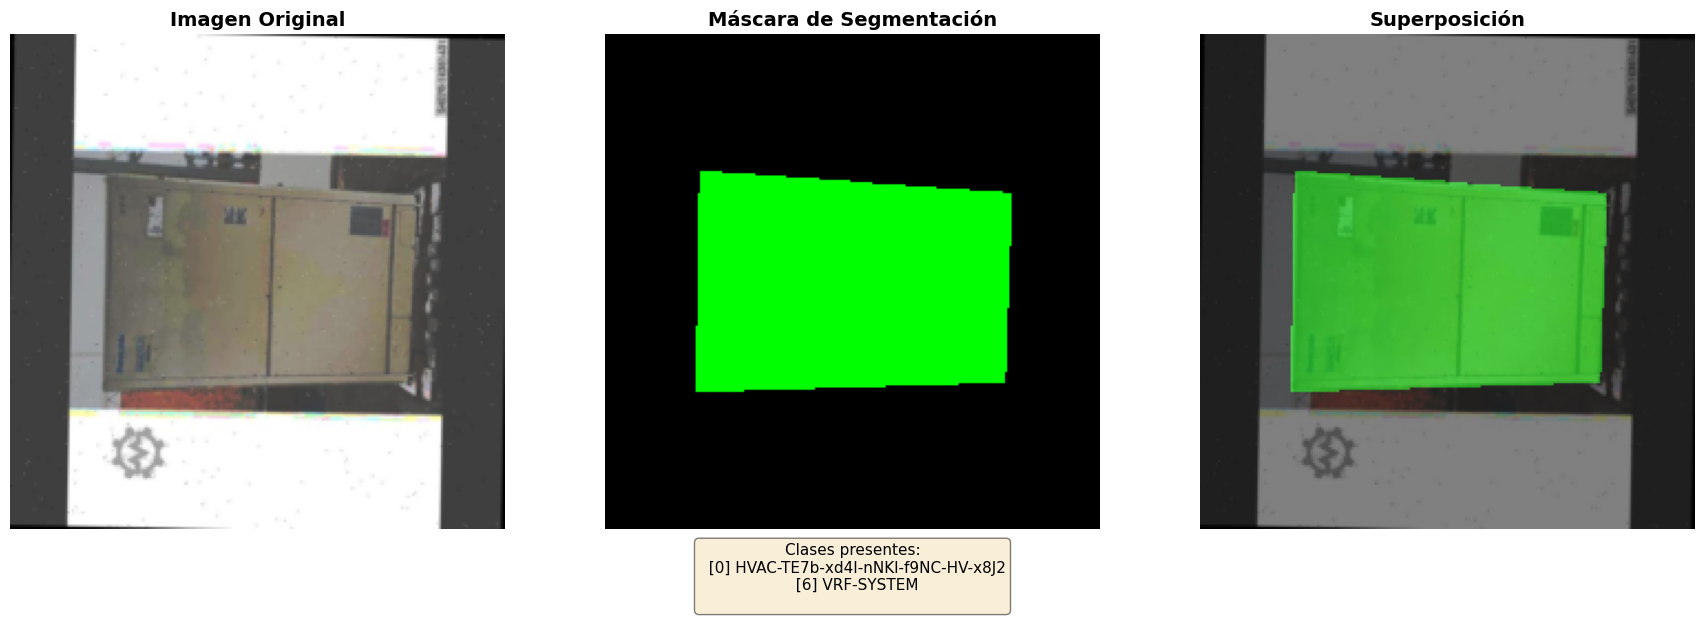

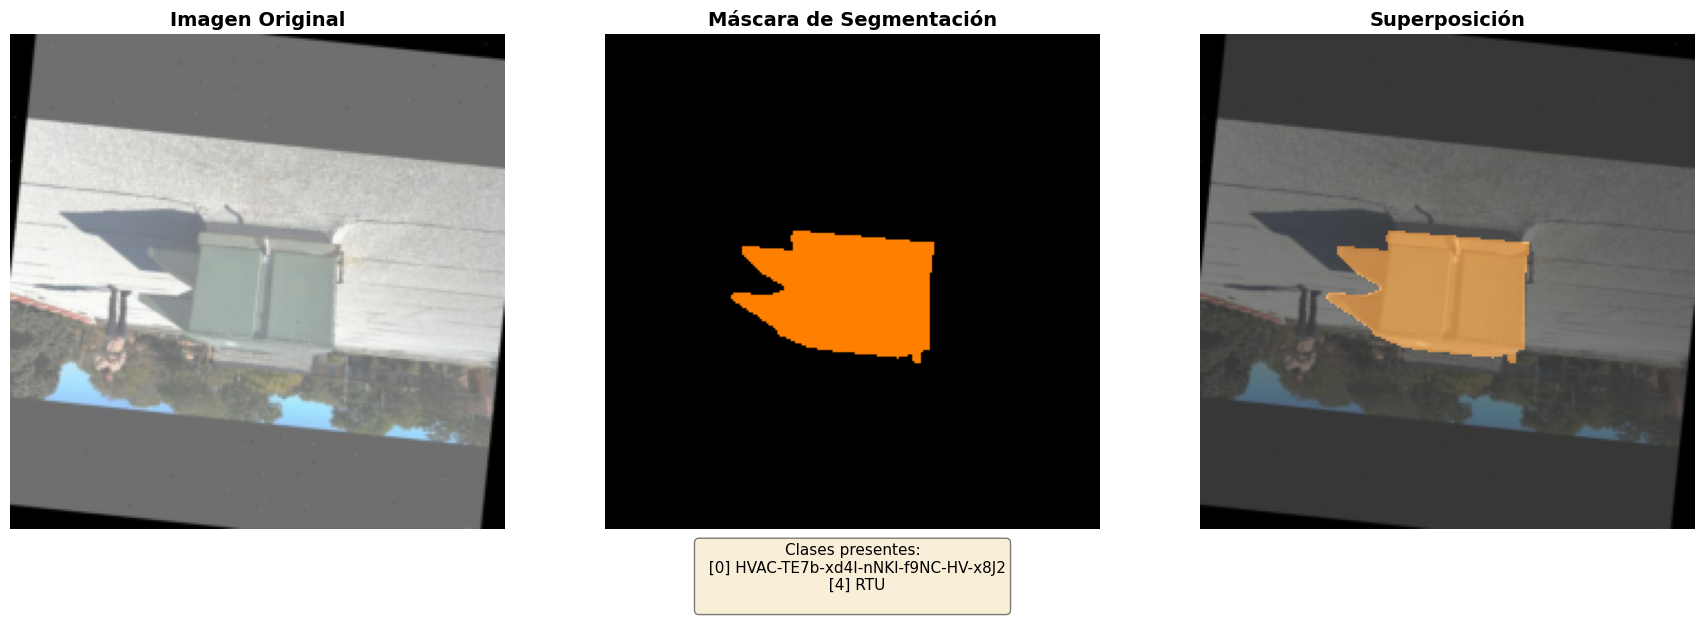

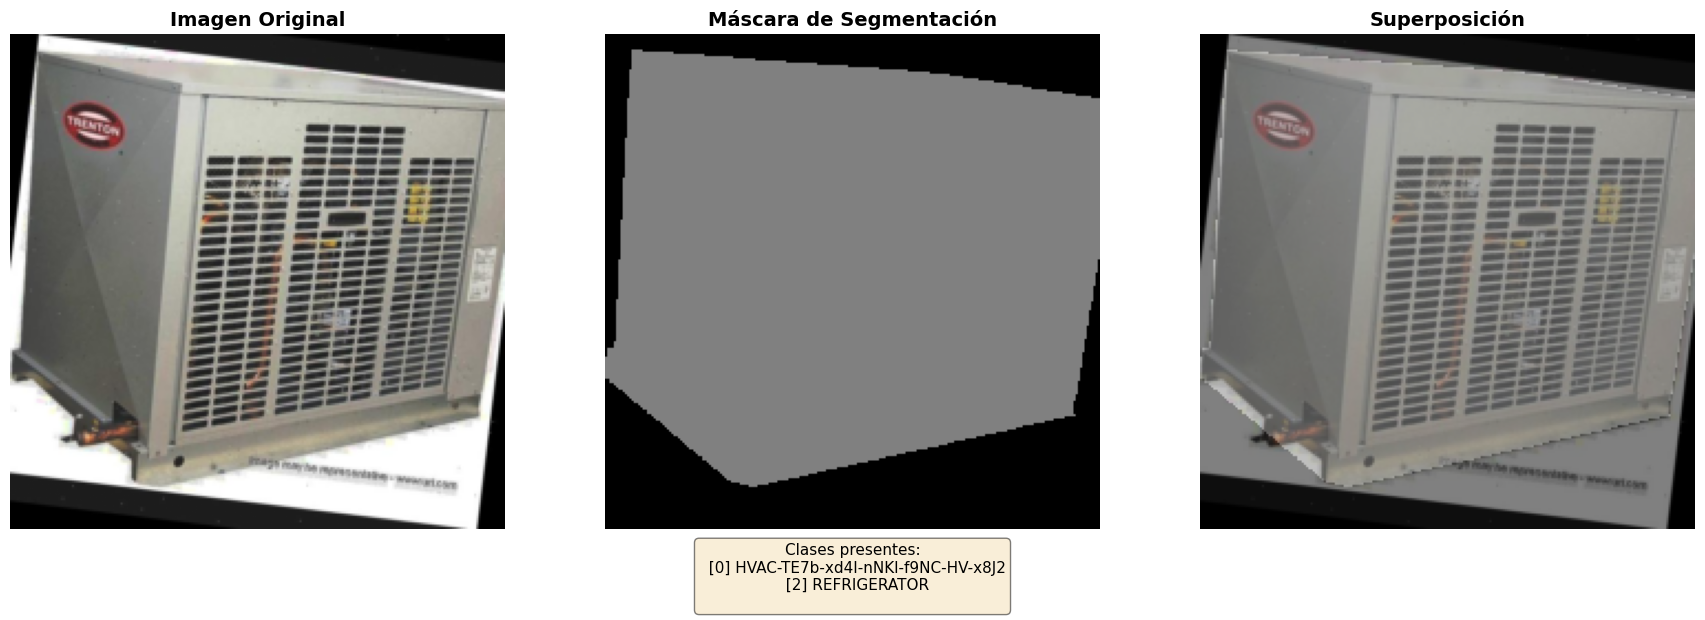

In [28]:
def visualize_sample(dataset, idx, class_names, color_palette):
    """Visualiza una imagen con su máscara de segmentación"""
    img, mask = dataset[idx]
    
    # Desnormalizar imagen
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_denorm = img * std + mean
    img_denorm = img_denorm.permute(1, 2, 0).numpy()
    img_denorm = np.clip(img_denorm, 0, 1)
    
    # Crear máscara coloreada
    mask_np = mask.numpy()
    mask_colored = np.zeros((*mask_np.shape, 3), dtype=np.uint8)
    for class_id in range(len(class_names)):
        mask_colored[mask_np == class_id] = color_palette[class_id]
    
    # Visualizar
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(img_denorm)
    axes[0].set_title('Imagen Original', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(mask_colored)
    axes[1].set_title('Máscara de Segmentación', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(img_denorm)
    axes[2].imshow(mask_colored, alpha=0.5)
    axes[2].set_title('Superposición', fontsize=14, fontweight='bold')
    axes[2].axis('off')
    
    # Leyenda
    unique_classes = np.unique(mask_np)
    legend_text = "Clases presentes:\n"
    for class_id in unique_classes:
        legend_text += f"  [{class_id}] {class_names[class_id]}\n"
    
    fig.text(0.5, 0.02, legend_text, ha='center', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()

# Visualizar muestras aleatorias
print("Visualizando muestras del dataset de entrenamiento:")
print("=" * 70)
for i in np.random.choice(len(train_dataset), min(3, len(train_dataset)), replace=False):
    visualize_sample(train_dataset, i, CLASS_NAMES, COLOR_PALETTE)

## 8. Crear Modelo DeepLabV3 + MobileNetV3

In [29]:
# Crear modelo con pesos pre-entrenados de COCO (21 clases)
print("Cargando modelo pre-entrenado de COCO...")
model = deeplabv3_mobilenet_v3_large(
    weights='DEFAULT',  # Pesos COCO pre-entrenados (21 clases)
    aux_loss=True
)

# Modificar la última capa del clasificador para tus 13 clases (Transfer Learning)
print(f"Adaptando modelo de 21 clases (COCO) a {NUM_CLASSES} clases (HVAC)...")

# Modificar el clasificador principal (última capa)
# Estructura: classifier[0-3]: capas intermedias, classifier[4]: capa final
model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)

# Modificar el clasificador auxiliar (COMPLETO - necesita reconstrucción)
if hasattr(model, 'aux_classifier') and model.aux_classifier is not None:
    # El aux_classifier de MobileNetV3 tiene una estructura diferente
    # Necesitamos reemplazar toda la secuencia
    in_channels = model.aux_classifier[0].in_channels  # Obtener canales de entrada originales
    model.aux_classifier = nn.Sequential(
        nn.Conv2d(in_channels, 256, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.1),
        nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
    )

# Inicializar las nuevas capas
nn.init.kaiming_normal_(model.classifier[4].weight, mode='fan_out', nonlinearity='relu')
nn.init.constant_(model.classifier[4].bias, 0)

if hasattr(model, 'aux_classifier') and model.aux_classifier is not None:
    for m in model.aux_classifier.modules():
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)

model = model.to(device)

# Contar parámetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 70)
print("MODELO: DeepLabV3 + MobileNetV3-Large (TRANSFER LEARNING)")
print("=" * 70)
print(f"✓ Backbone: MobileNetV3-Large (COCO pre-entrenado)")
print(f"✓ Clasificador principal: Adaptado para {NUM_CLASSES} clases")
print(f"✓ Clasificador auxiliar: Reconstruido para {NUM_CLASSES} clases")
print(f"✓ Estrategia: Fine-tuning completo")
print(f"\nParámetros totales: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")
print(f"Tamaño estimado: {total_params * 4 / 1024 / 1024:.2f} MB (FP32)")
print("=" * 70)

Cargando modelo pre-entrenado de COCO...
Adaptando modelo de 21 clases (COCO) a 8 clases (HVAC)...
MODELO: DeepLabV3 + MobileNetV3-Large (TRANSFER LEARNING)
✓ Backbone: MobileNetV3-Large (COCO pre-entrenado)
✓ Clasificador principal: Adaptado para 8 clases
✓ Clasificador auxiliar: Reconstruido para 8 clases
✓ Estrategia: Fine-tuning completo

Parámetros totales: 11,116,864
Parámetros entrenables: 11,116,864
Tamaño estimado: 42.41 MB (FP32)


## 9. Configuración de Entrenamiento

In [31]:
# Hiperparámetros
NUM_EPOCHS = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# Loss function (Cross Entropy para segmentación)
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Learning rate scheduler
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=7
)

# Mixed precision scaler
scaler = torch.cuda.amp.GradScaler()

print("✓ Configuración de entrenamiento lista!")
print(f"Épocas: {NUM_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Mixed precision: Habilitado (FP16)")
print(f"LR Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

✓ Configuración de entrenamiento lista!
Épocas: 100
Learning rate: 0.001
Batch size: 16
Mixed precision: Habilitado (FP16)
LR Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


## 10. Funciones de Entrenamiento

In [32]:
def calculate_iou(pred, target, num_classes):
    """Calcula IoU (Intersection over Union) promedio"""
    ious = []
    pred = pred.view(-1)
    target = target.view(-1)
    
    for cls in range(num_classes):
        pred_inds = pred == cls
        target_inds = target == cls
        intersection = (pred_inds & target_inds).sum().float()
        union = (pred_inds | target_inds).sum().float()
        
        if union == 0:
            ious.append(float('nan'))  # Clase no presente
        else:
            ious.append((intersection / union).item())
    
    # Calcular mean IoU ignorando NaN
    ious = [iou for iou in ious if not np.isnan(iou)]
    return np.mean(ious) if ious else 0.0


def train_one_epoch(model, dataloader, optimizer, criterion, scaler, device, epoch):
    """Entrena una época"""
    model.train()
    total_loss = 0
    total_iou = 0
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch}", leave=True)
    
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass con mixed precision
        with torch.cuda.amp.autocast():
            outputs = model(images)
            # DeepLabV3 devuelve un dict con 'out' y 'aux'
            loss = criterion(outputs['out'], masks)
            if 'aux' in outputs:
                loss += 0.4 * criterion(outputs['aux'], masks)
        
        # Backward pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # Calcular IoU
        pred = outputs['out'].argmax(dim=1)
        iou = calculate_iou(pred, masks, NUM_CLASSES)
        
        total_loss += loss.item()
        total_iou += iou
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'IoU': f'{iou:.4f}'
        })
    
    avg_loss = total_loss / len(dataloader)
    avg_iou = total_iou / len(dataloader)
    
    return avg_loss, avg_iou


def validate(model, dataloader, criterion, device):
    """Valida el modelo"""
    model.eval()
    total_loss = 0
    total_iou = 0
    
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Validating", leave=False):
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs['out'], masks)
            
            pred = outputs['out'].argmax(dim=1)
            iou = calculate_iou(pred, masks, NUM_CLASSES)
            
            total_loss += loss.item()
            total_iou += iou
    
    avg_loss = total_loss / len(dataloader)
    avg_iou = total_iou / len(dataloader)
    
    return avg_loss, avg_iou

print("✓ Funciones de entrenamiento listas!")

✓ Funciones de entrenamiento listas!


## 11. Loop de Entrenamiento Principal

In [33]:
# Historial de entrenamiento
history = {
    'train_loss': [],
    'train_iou': [],
    'val_loss': [],
    'val_iou': [],
    'lr': []
}

best_val_iou = 0.0
patience_counter = 0
MAX_PATIENCE = 10

print("=" * 70)
print("INICIANDO ENTRENAMIENTO")
print("=" * 70)

import time
start_time = time.time()

try:
    for epoch in range(1, NUM_EPOCHS + 1):
        epoch_start = time.time()
        
        # Entrenar
        train_loss, train_iou = train_one_epoch(
            model, train_loader, optimizer, criterion, scaler, device, epoch
        )
        
        # Validar
        val_loss, val_iou = validate(model, valid_loader, criterion, device)
        
        # Actualizar learning rate
        lr_scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Guardar historial
        history['train_loss'].append(train_loss)
        history['train_iou'].append(train_iou)
        history['val_loss'].append(val_loss)
        history['val_iou'].append(val_iou)
        history['lr'].append(current_lr)
        
        epoch_time = time.time() - epoch_start
        
        # Imprimir resumen
        print(f"\n{'='*70}")
        print(f"Epoch {epoch}/{NUM_EPOCHS}")
        print(f"Train - Loss: {train_loss:.4f} | IoU: {train_iou:.4f}")
        print(f"Valid - Loss: {val_loss:.4f} | IoU: {val_iou:.4f}")
        print(f"LR: {current_lr:.6f} | Time: {epoch_time:.1f}s")
        
        # Guardar mejor modelo (basado en IoU)
        if val_iou > best_val_iou:
            best_val_iou = val_iou
            # Guardar modelo completo (con optimizer, 188MB)
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_iou': val_iou,
                'val_loss': val_loss,
            }, '/workspace/data/best_segmentation_model.pth')
            
            # OPCIONAL: Guardar solo pesos del modelo (sin optimizer, ~18MB)
            torch.save(
                model.state_dict(),
                '/workspace/data/best_segmentation_model_lightweight.pth'
            )
            print(f"✓ Mejor modelo guardado! (IoU: {val_iou:.4f})")
            patience_counter = 0
        else:
            patience_counter += 1
        
        # Early stopping
        if patience_counter >= MAX_PATIENCE:
            print(f"\n⚠ Early stopping después de {epoch} épocas")
            break
        
        print("=" * 70)

except KeyboardInterrupt:
    print("\n⚠ Entrenamiento interrumpido por el usuario")

finally:
    total_time = time.time() - start_time
    print(f"\n{'='*70}")
    print("ENTRENAMIENTO COMPLETADO")
    print(f"{'='*70}")
    print(f"Tiempo total: {total_time/60:.2f} minutos")
    print(f"Mejor IoU de validación: {best_val_iou:.4f}")
    print(f"Modelo guardado en: /workspace/data/best_segmentation_model.pth")
    print("=" * 70)

INICIANDO ENTRENAMIENTO


Epoch 1:   0%|          | 0/299 [00:00<?, ?it/s]

Validating:   0%|          | 0/9 [00:00<?, ?it/s]


Epoch 1/100
Train - Loss: 0.7952 | IoU: 0.4828
Valid - Loss: 0.1400 | IoU: 0.6208
LR: 0.001000 | Time: 93.4s
✓ Mejor modelo guardado! (IoU: 0.6208)


Epoch 2:   0%|          | 0/299 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/9 [00:00<?, ?it/s]


Epoch 37/100
Train - Loss: 0.0626 | IoU: 0.9122
Valid - Loss: 0.1562 | IoU: 0.7526
LR: 0.000063 | Time: 39.4s


Epoch 38:   0%|          | 0/299 [00:00<?, ?it/s]

Validating:   0%|          | 0/9 [00:00<?, ?it/s]


Epoch 38/100
Train - Loss: 0.0621 | IoU: 0.9109
Valid - Loss: 0.1541 | IoU: 0.7573
LR: 0.000063 | Time: 44.2s

⚠ Early stopping después de 38 épocas

ENTRENAMIENTO COMPLETADO
Tiempo total: 26.14 minutos
Mejor IoU de validación: 0.7719
Modelo guardado en: /workspace/data/best_segmentation_model.pth


## 12. Visualizar Curvas de Entrenamiento

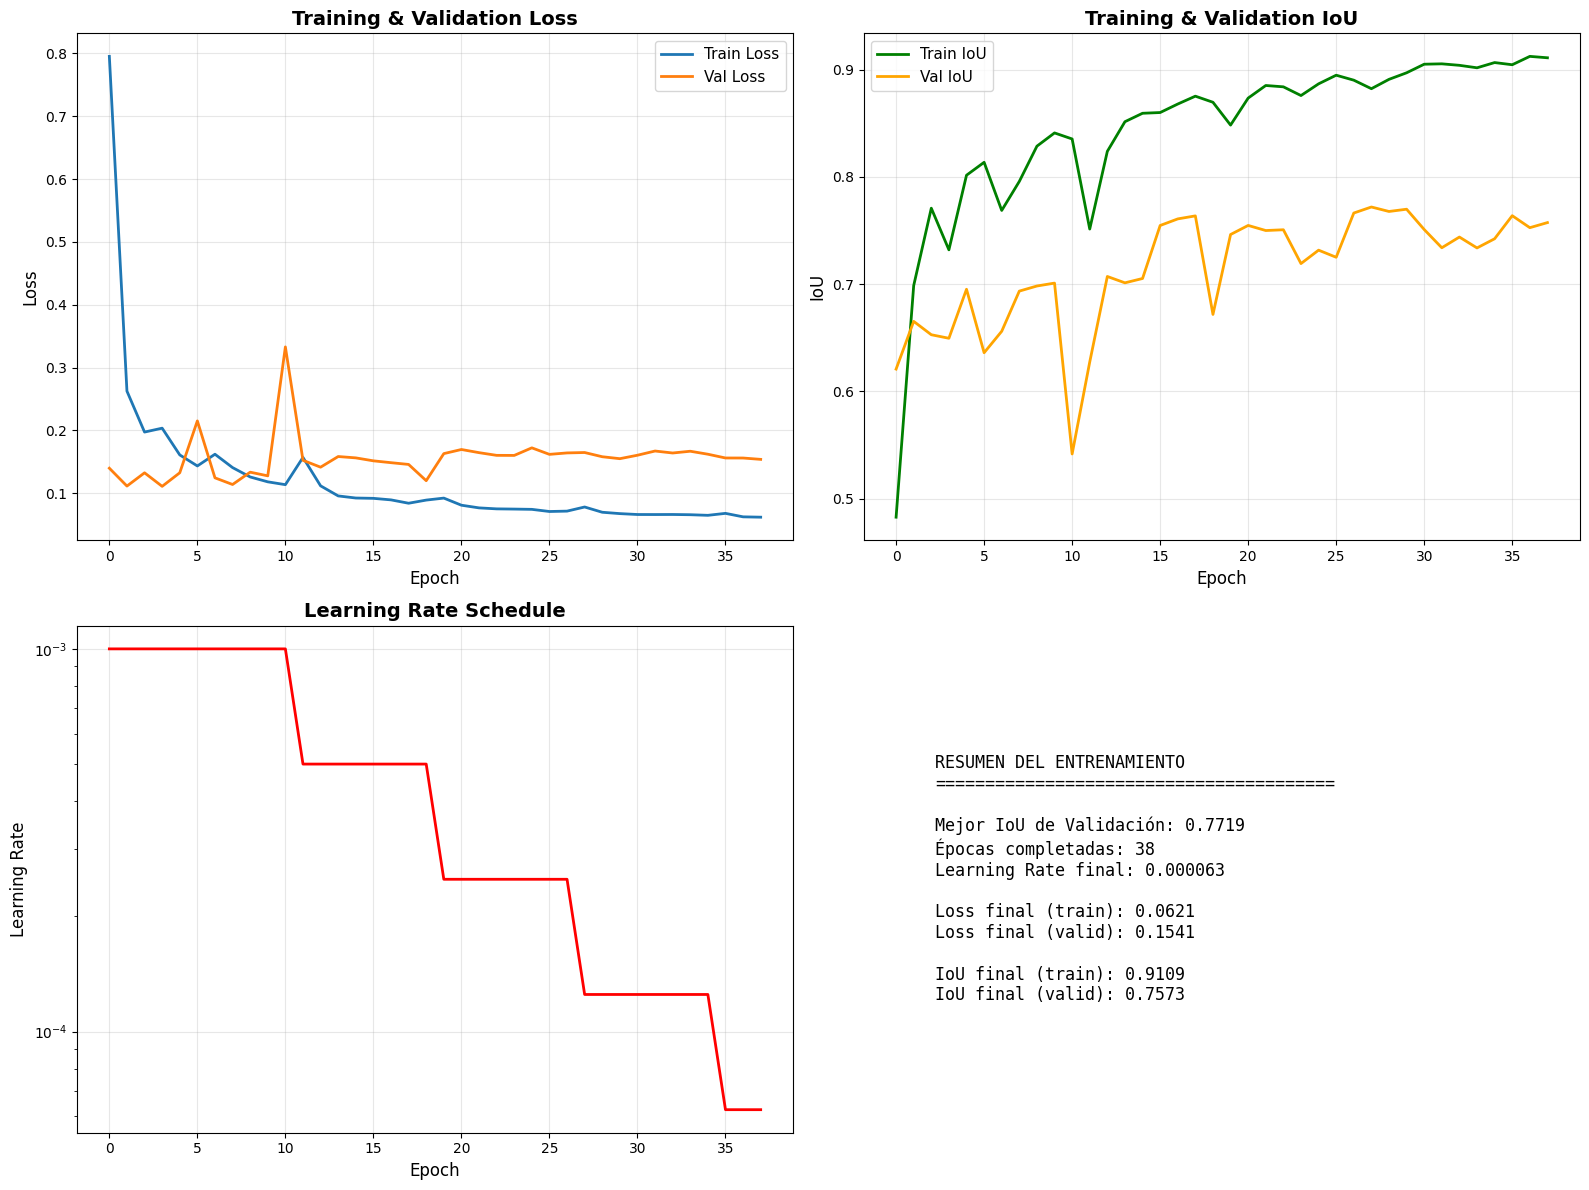

✓ Curvas guardadas en /workspace/data/training_curves_segmentation.png


In [34]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# IoU
axes[0, 1].plot(history['train_iou'], label='Train IoU', linewidth=2, color='green')
axes[0, 1].plot(history['val_iou'], label='Val IoU', linewidth=2, color='orange')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('IoU', fontsize=12)
axes[0, 1].set_title('Training & Validation IoU', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# Learning Rate
axes[1, 0].plot(history['lr'], color='red', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Learning Rate', fontsize=12)
axes[1, 0].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Resumen
axes[1, 1].axis('off')
summary_text = f"""
RESUMEN DEL ENTRENAMIENTO
{'='*40}

Mejor IoU de Validación: {best_val_iou:.4f}
Épocas completadas: {len(history['train_loss'])}
Learning Rate final: {history['lr'][-1]:.6f}

Loss final (train): {history['train_loss'][-1]:.4f}
Loss final (valid): {history['val_loss'][-1]:.4f}

IoU final (train): {history['train_iou'][-1]:.4f}
IoU final (valid): {history['val_iou'][-1]:.4f}
"""
axes[1, 1].text(0.1, 0.5, summary_text, fontsize=12, family='monospace',
               verticalalignment='center')

plt.tight_layout()
plt.savefig('/workspace/data/training_curves_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Curvas guardadas en /workspace/data/training_curves_segmentation.png")

## 13. Extraer Backbone Entrenado

In [35]:
# Cargar mejor modelo
checkpoint = torch.load('/workspace/data/best_segmentation_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✓ Modelo cargado (época {checkpoint['epoch']})")
print(f"✓ Mejor IoU: {checkpoint['val_iou']:.4f}")

# Extraer backbone
trained_backbone = model.backbone

# Guardar backbone (solo pesos del backbone, mucho más liviano)
torch.save(
    trained_backbone.state_dict(),
    '/workspace/data/backbone_segmentation_trained.pth'
)

print("\n✓ Backbone entrenado extraído y guardado!")
print(f"   Ruta: /workspace/data/backbone_segmentation_trained.pth")
print(f"\nEste backbone ahora tiene features optimizadas para:")
for i, class_name in enumerate(CLASS_NAMES):
    print(f"  • {class_name}")

✓ Modelo cargado (época 28)
✓ Mejor IoU: 0.7719

✓ Backbone entrenado extraído y guardado!
   Ruta: /workspace/data/backbone_segmentation_trained.pth

Este backbone ahora tiene features optimizadas para:
  • HVAC-TE7b-xd4I-nNKl-f9NC-HV-x8J2
  • GRAVITY-VENT
  • REFRIGERATOR
  • RESIDENTIAL-UNIT
  • RTU
  • SPLIT-SYSTEM
  • VRF-SYSTEM
  • WINDOW-UNIT


## 14. Visualizar Predicciones del Modelo

Predicciones del modelo en el conjunto de validación:


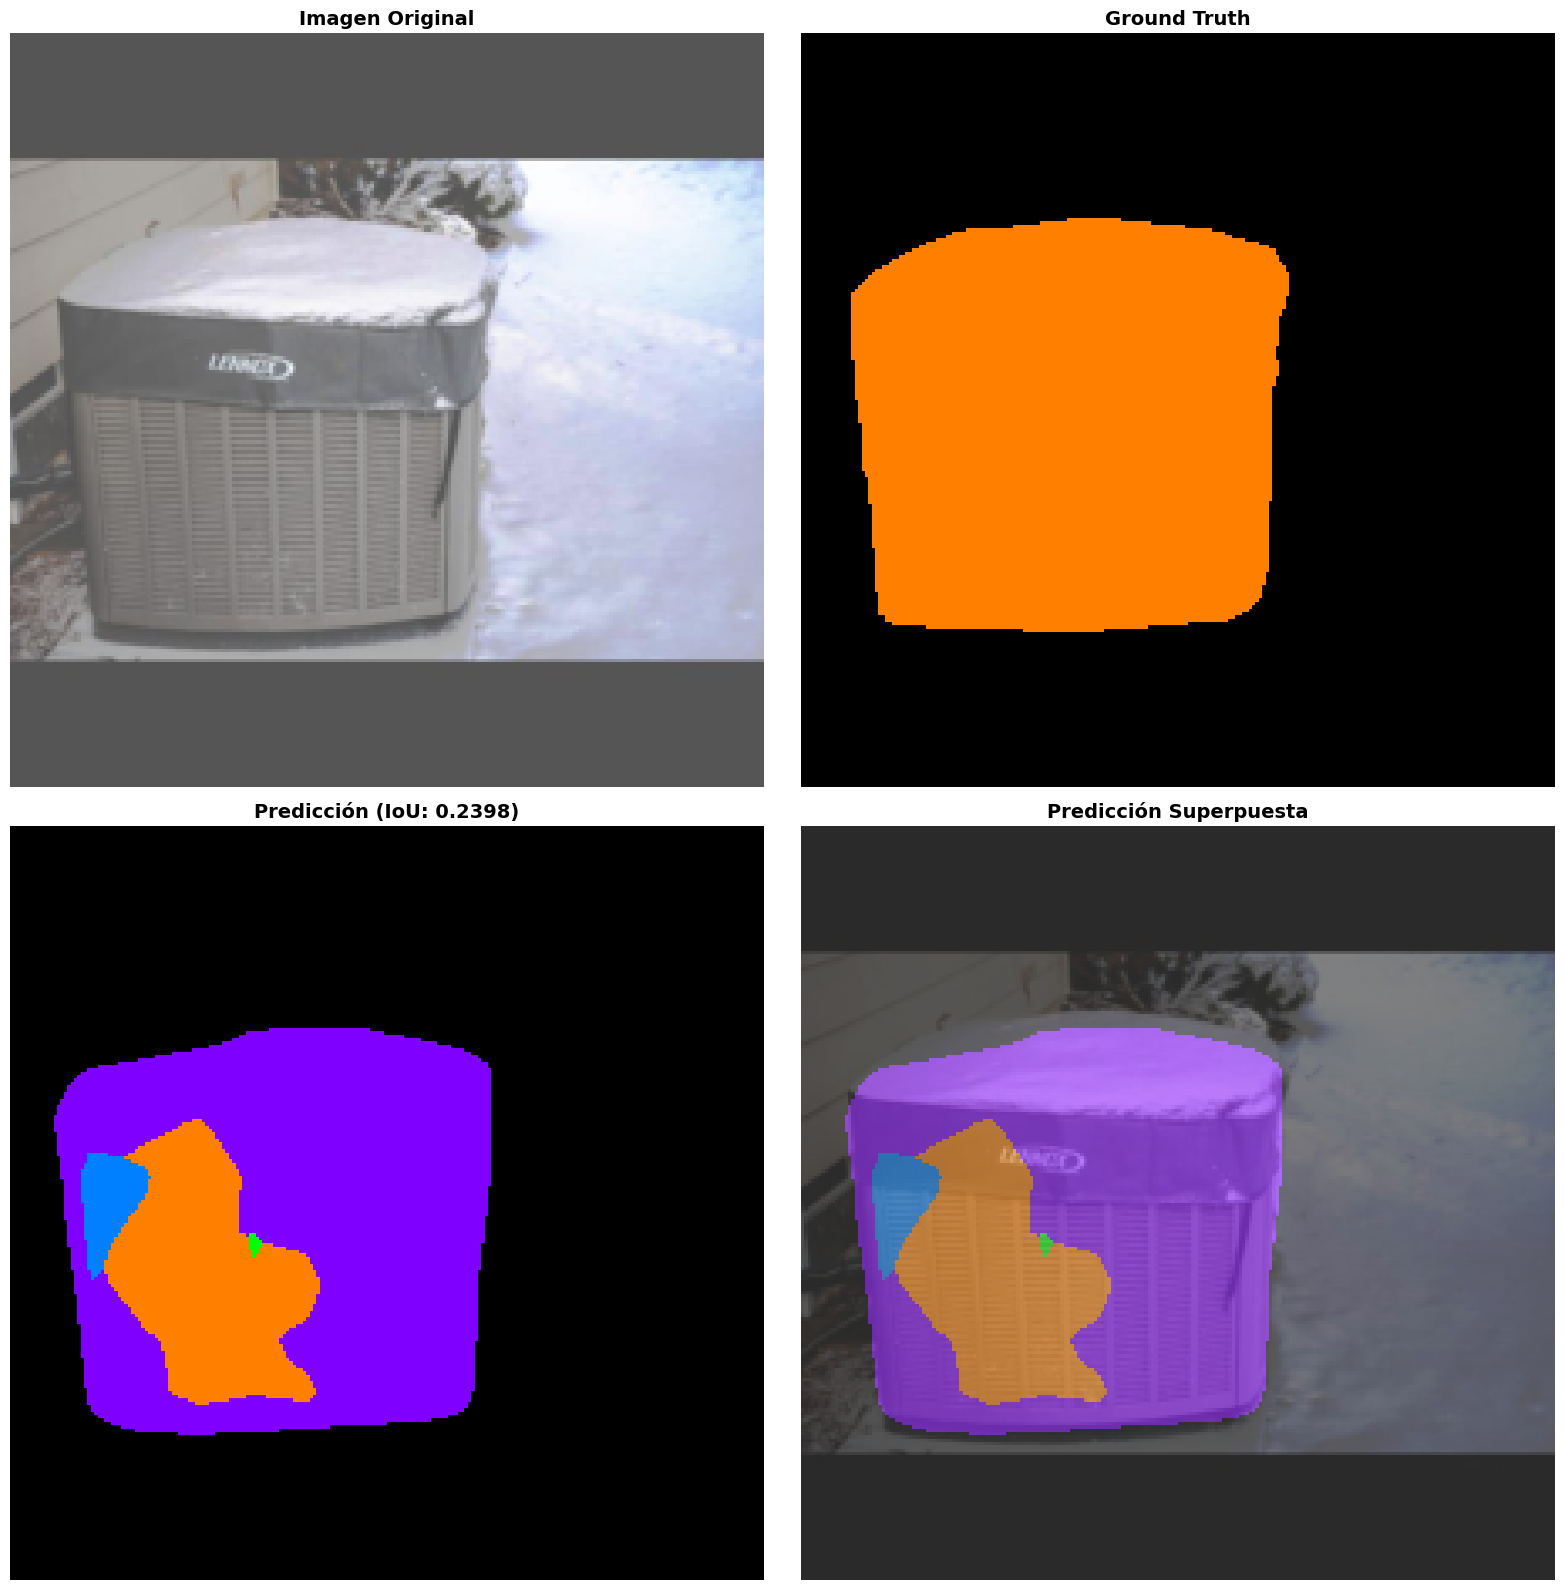

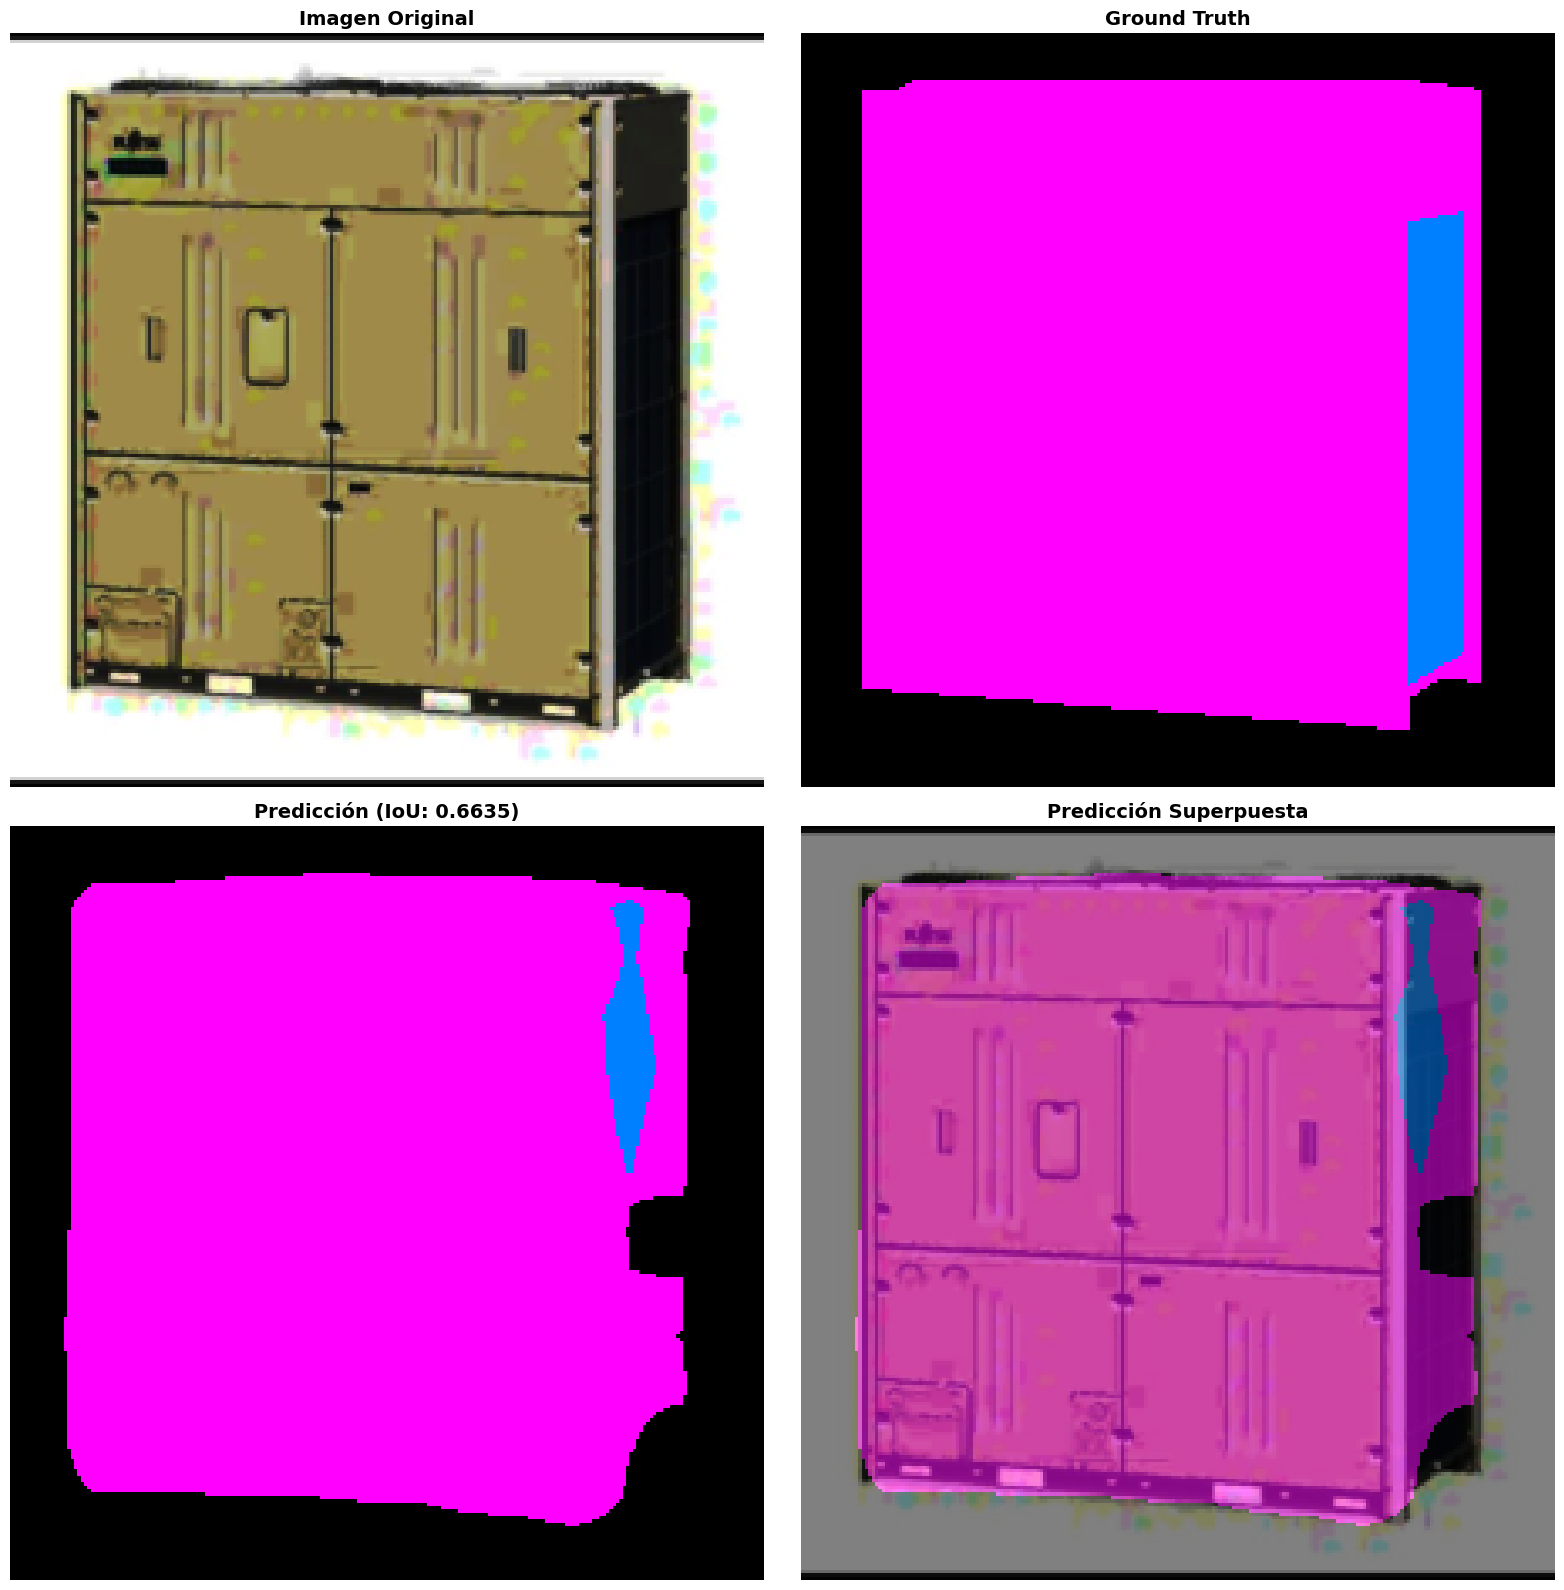

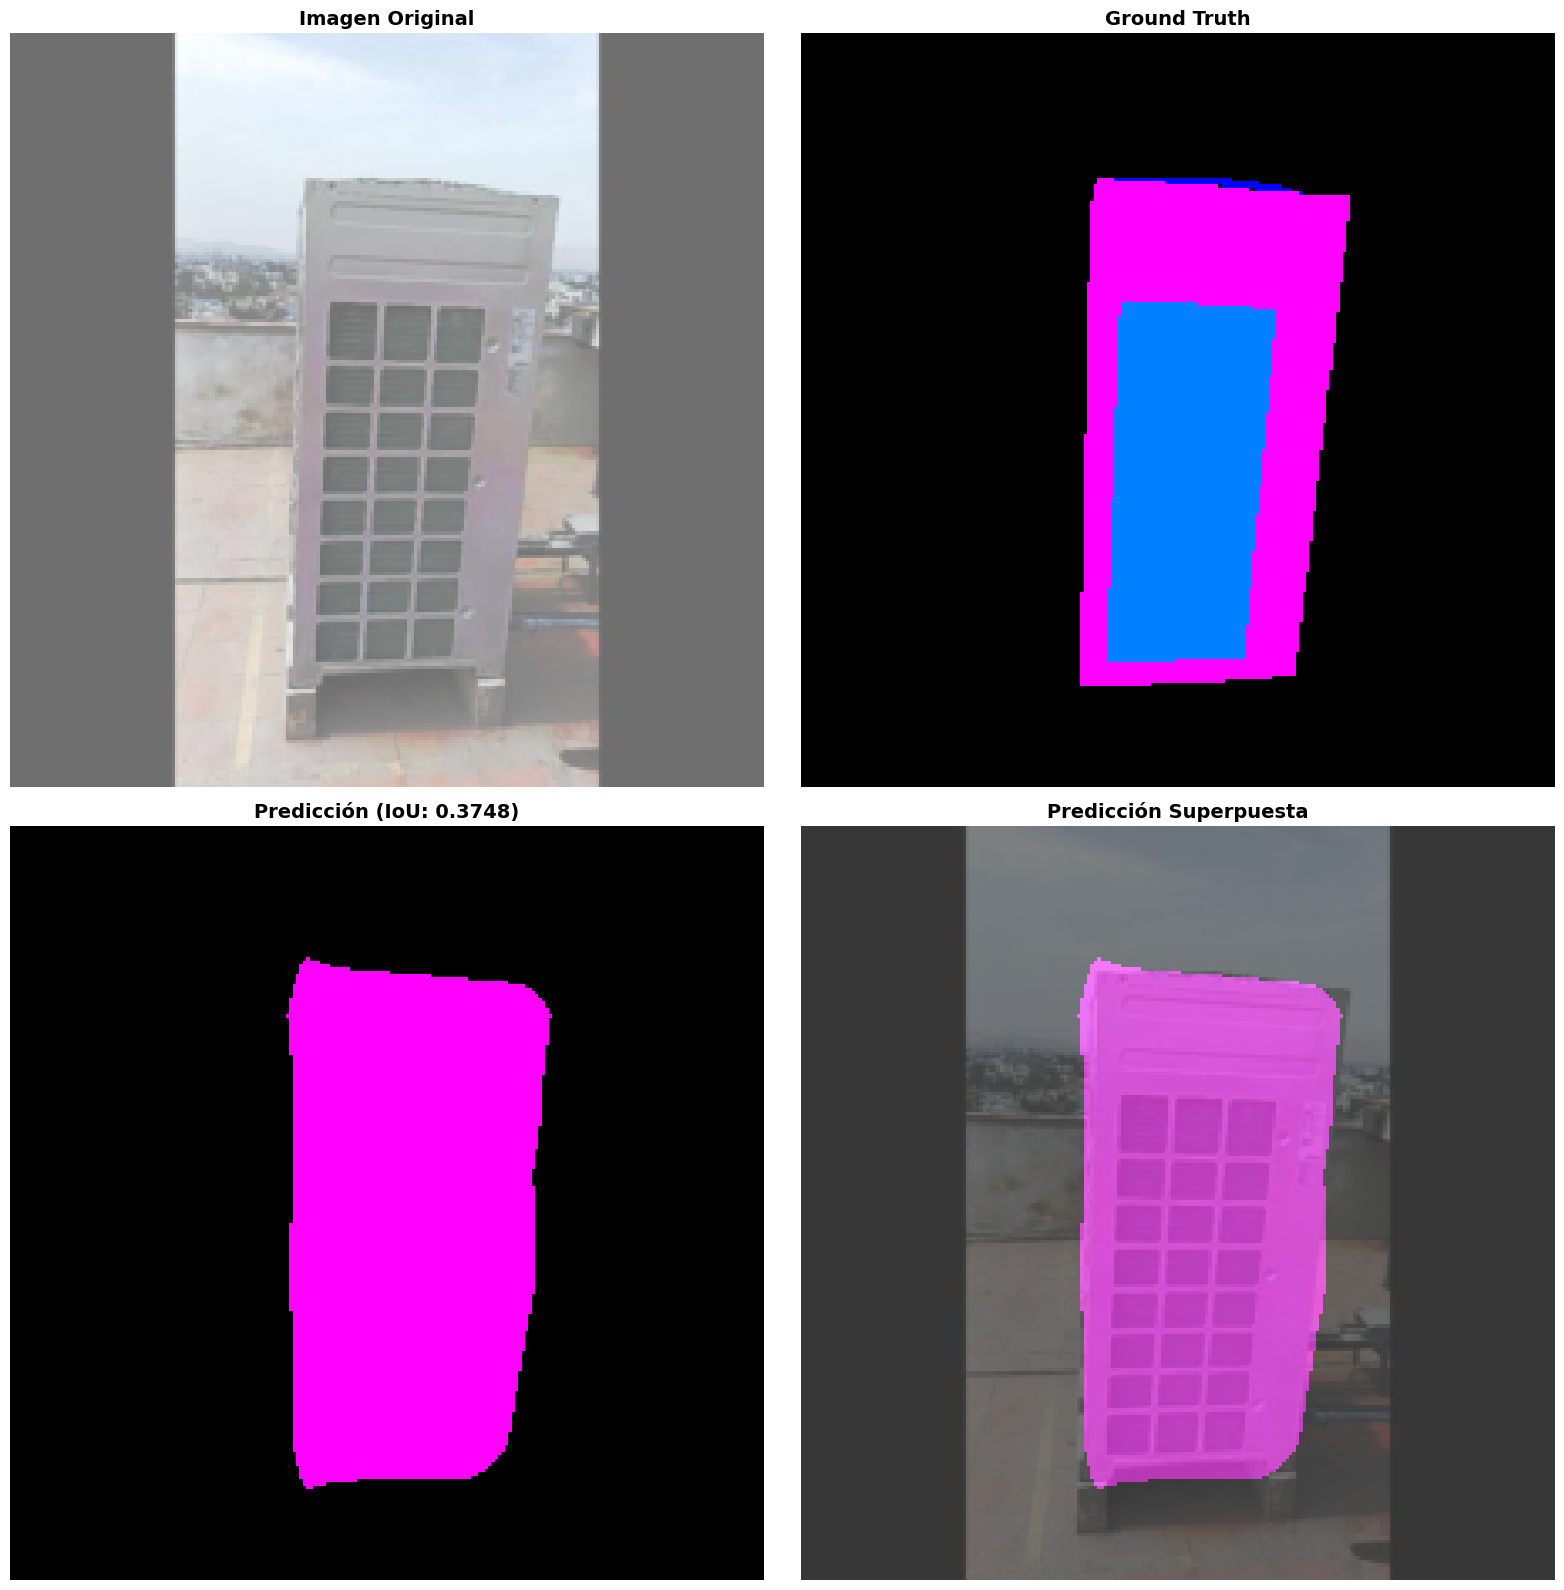

In [17]:
def visualize_prediction(model, dataset, idx, class_names, color_palette):
    """Visualiza predicción del modelo"""
    model.eval()
    
    img, mask_gt = dataset[idx]
    
    # Predicción
    with torch.no_grad():
        output = model(img.unsqueeze(0).to(device))
        pred = output['out'].argmax(dim=1).squeeze(0).cpu().numpy()
    
    # Desnormalizar imagen
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_denorm = img * std + mean
    img_denorm = img_denorm.permute(1, 2, 0).numpy()
    img_denorm = np.clip(img_denorm, 0, 1)
    
    # Crear máscaras coloreadas
    mask_gt_np = mask_gt.numpy()
    mask_gt_colored = np.zeros((*mask_gt_np.shape, 3), dtype=np.uint8)
    mask_pred_colored = np.zeros((*pred.shape, 3), dtype=np.uint8)
    
    for class_id in range(len(class_names)):
        mask_gt_colored[mask_gt_np == class_id] = color_palette[class_id]
        mask_pred_colored[pred == class_id] = color_palette[class_id]
    
    # Calcular IoU
    iou = calculate_iou(torch.from_numpy(pred), mask_gt, len(class_names))
    
    # Visualizar
    fig, axes = plt.subplots(2, 2, figsize=(16, 16))
    
    axes[0, 0].imshow(img_denorm)
    axes[0, 0].set_title('Imagen Original', fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(mask_gt_colored)
    axes[0, 1].set_title('Ground Truth', fontsize=14, fontweight='bold')
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(mask_pred_colored)
    axes[1, 0].set_title(f'Predicción (IoU: {iou:.4f})', fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(img_denorm)
    axes[1, 1].imshow(mask_pred_colored, alpha=0.5)
    axes[1, 1].set_title('Predicción Superpuesta', fontsize=14, fontweight='bold')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualizar predicciones en validación
print("Predicciones del modelo en el conjunto de validación:")
print("=" * 70)
for i in np.random.choice(len(valid_dataset), min(3, len(valid_dataset)), replace=False):
    visualize_prediction(model, valid_dataset, i, CLASS_NAMES, COLOR_PALETTE)

## 15. Comparar Mapas de Atención: COCO vs Entrenado

Esta es la parte clave: visualizar cómo cambió la atención del backbone después del entrenamiento.

In [19]:
# Importar funciones de visualización desde utils
import sys
sys.path.append('/workspace/notebooks')
from utils import compare_backbone_attention, visualize_embedding_attention

# Cargar modelo vanilla (COCO pre-entrenado)
vanilla_model = deeplabv3_mobilenet_v3_large(weights='DEFAULT', num_classes=21)
vanilla_model = vanilla_model.to(device)
vanilla_model.eval()

# Tu backbone entrenado ya está cargado como trained_backbone

# Preprocessing
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225]),
])

print("✓ Modelos listos para comparación de atención")

✓ Modelos listos para comparación de atención


Usando imagen de ejemplo: assets/vrf/rtu.jpg

COMPARACIÓN DE MAPAS DE ATENCIÓN

1. BACKBONE COCO PRE-ENTRENADO (sin fine-tuning)
----------------------------------------------------------------------


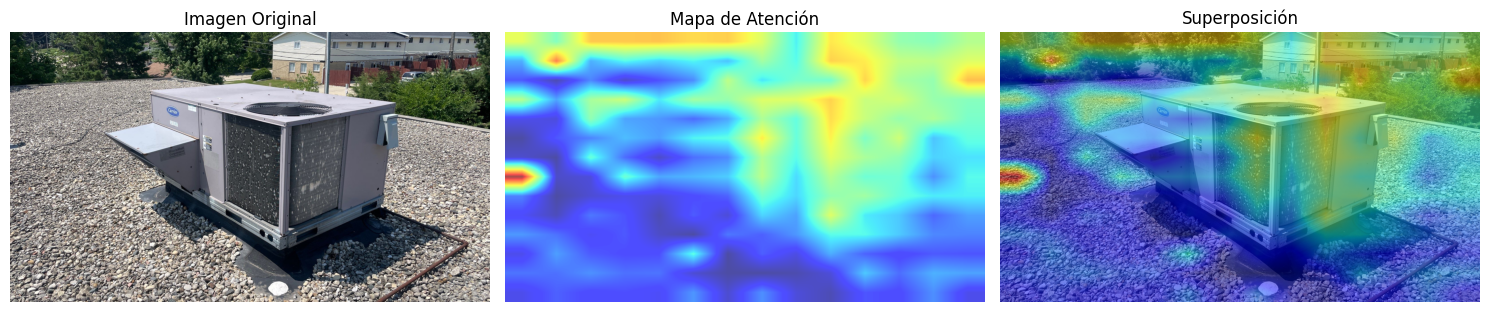


2. BACKBONE ENTRENADO EN TUS CLASES
----------------------------------------------------------------------


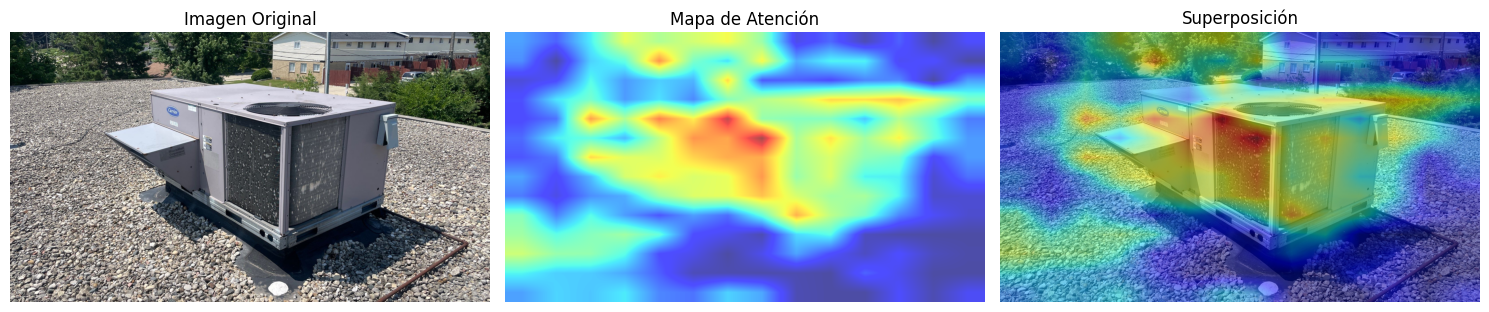


3. COMPARACIÓN LADO A LADO
----------------------------------------------------------------------


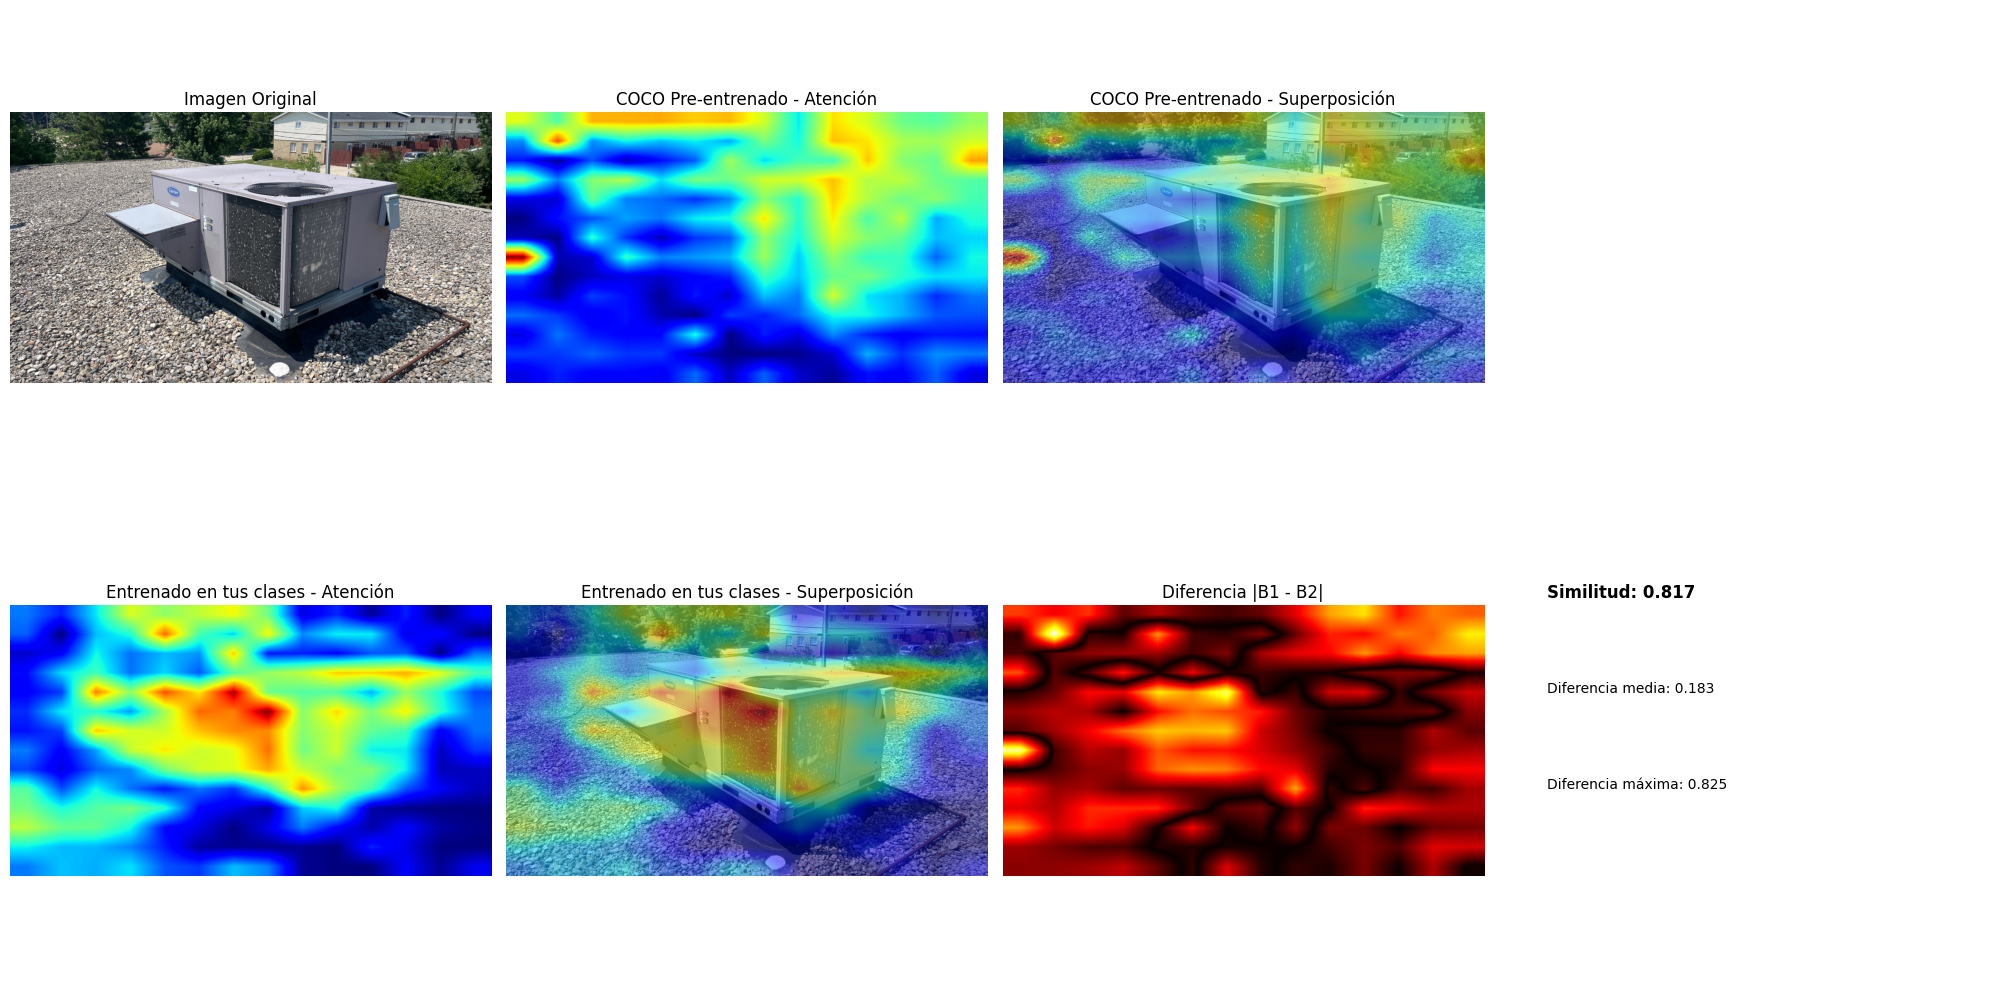


INTERPRETACIÓN DE LOS MAPAS DE ATENCIÓN

🔴 ROJO/AMARILLO = Alta activación (regiones importantes)
🟢 VERDE = Activación media
🔵 AZUL = Baja activación (regiones ignoradas)

CAMBIOS ESPERADOS después del entrenamiento:
✓ Atención más concentrada en componentes específicos de tu dataset
✓ Menor dispersión en áreas irrelevantes (fondo, sombras)
✓ Mayor activación en regiones con tus clases de interés

COMPARACIÓN:
• Similitud < 0.5 → Los backbones atienden regiones MUY diferentes (BUENO!)
• Similitud > 0.8 → Los backbones son casi idénticos (poco cambio)
    


In [36]:
# Seleccionar una imagen de ejemplo
# Usa una imagen de tu dataset de validación
import os

# Obtener lista de imágenes de validación
valid_images_dir = DATASET_PATH / "valid" / "images" if (DATASET_PATH / "valid" / "images").exists() else DATASET_PATH / "valid"
sample_images = list(valid_images_dir.glob("*.jpg")) + list(valid_images_dir.glob("*.png"))

if len(sample_images) > 0:
    # Usar la primera imagen como ejemplo
    #sample_image_path = str(sample_images[0])
    sample_image_path = "assets/vrf/rtu.jpg"
    print(f"Usando imagen de ejemplo: {sample_image_path}")
    
    print("\n" + "="*70)
    print("COMPARACIÓN DE MAPAS DE ATENCIÓN")
    print("="*70)
    print("\n1. BACKBONE COCO PRE-ENTRENADO (sin fine-tuning)")
    print("-" * 70)
    
    # Visualizar atención del modelo vanilla
    visualize_embedding_attention(
        sample_image_path,
        vanilla_model,
        preprocess,
        device='cuda'
    )
    
    print("\n2. BACKBONE ENTRENADO EN TUS CLASES")
    print("-" * 70)
    
    # Visualizar atención del modelo entrenado
    visualize_embedding_attention(
        sample_image_path,
        model,
        preprocess,
        device='cuda'
    )
    
    print("\n3. COMPARACIÓN LADO A LADO")
    print("-" * 70)
    
    # Comparar ambos backbones
    compare_backbone_attention(
        sample_image_path,
        vanilla_model.backbone,
        trained_backbone,
        preprocess,
        name1="COCO Pre-entrenado",
        name2="Entrenado en tus clases",
        device='cuda'
    )
    
    print("\n" + "="*70)
    print("INTERPRETACIÓN DE LOS MAPAS DE ATENCIÓN")
    print("="*70)
    print("""
🔴 ROJO/AMARILLO = Alta activación (regiones importantes)
🟢 VERDE = Activación media
🔵 AZUL = Baja activación (regiones ignoradas)

CAMBIOS ESPERADOS después del entrenamiento:
✓ Atención más concentrada en componentes específicos de tu dataset
✓ Menor dispersión en áreas irrelevantes (fondo, sombras)
✓ Mayor activación en regiones con tus clases de interés

COMPARACIÓN:
• Similitud < 0.5 → Los backbones atienden regiones MUY diferentes (BUENO!)
• Similitud > 0.8 → Los backbones son casi idénticos (poco cambio)
    """)
    print("="*70)
    
else:
    print("❌ No se encontraron imágenes de validación")
    print("   Usa tus propias imágenes para comparar")
    print("\nEjemplo de uso:")
    print("""
from utils import compare_backbone_attention

compare_backbone_attention(
    "ruta/a/tu/imagen.jpg",
    vanilla_model.backbone,
    trained_backbone,
    preprocess,
    "COCO Pre-entrenado",
    "Entrenado en tus clases"
)
    """)

## 16. Resumen y Próximos Pasos

In [ ]:
print("="*70)
print("RESUMEN COMPLETO")
print("="*70)
print(f"""
✓ Modelo entrenado: DeepLabV3 + MobileNetV3-Large
✓ Número de clases: {NUM_CLASSES}
✓ Mejor IoU de validación: {best_val_iou:.4f}
✓ Épocas completadas: {len(history['train_loss'])}

ARCHIVOS GUARDADOS:
• Modelo completo: /workspace/data/best_segmentation_model.pth
• Backbone entrenado: /workspace/data/backbone_segmentation_trained.pth
• Curvas de entrenamiento: /workspace/data/training_curves_segmentation.png

CÓMO USAR EL BACKBONE EN TU NOTEBOOK DE EMBEDDINGS:

1. Cargar el backbone entrenado:
   ```python
   def load_trained_backbone(backbone_path):
       from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large
       model = deeplabv3_mobilenet_v3_large(weights=None, num_classes={NUM_CLASSES})
       backbone_state_dict = torch.load(backbone_path)
       model.backbone.load_state_dict(backbone_state_dict)
       return model.backbone
   
   trained_backbone = load_trained_backbone(
       '/workspace/data/backbone_segmentation_trained.pth'
   )
   ```

2. Usar con tu clase TrainedBackboneEmbeddings:
   ```python
   embedder = TrainedBackboneEmbeddings(
       'backbone_segmentation_trained.pth'
   )
   embeddings, paths = embedder.get_embeddings_from_folder("assets/")
   ```

3. Comparar con backbone vanilla:
   ```python
   from utils import compare_backbone_attention
   
   vanilla_model = deeplabv3_mobilenet_v3_large(weights='DEFAULT')
   
   compare_backbone_attention(
       "assets/vrf/snapshot_0.jpg",
       vanilla_model.backbone,
       trained_backbone,
       preprocess,
       "COCO",
       "Entrenado en {', '.join(CLASS_NAMES[1:])}"
   )
   ```

PRÓXIMOS PASOS:
1. Evaluar el modelo en más imágenes
2. Ajustar hiperparámetros si es necesario
3. Comparar embeddings generados con ambos backbones
4. Analizar qué backbone funciona mejor para tu tarea específica

""")
print("="*70)

## 17. Función para Extraer Embeddings

Función útil para extraer embeddings de cualquier imagen usando el backbone entrenado.

In [3]:
def get_embeddings_from_image(image_path, model_path, device='cuda', show_attention=True):
    """
    Extrae embeddings de una imagen usando un backbone entrenado.
    
    Args:
        image_path (str): Ruta a la imagen (absoluta o relativa)
        model_path (str): Ruta al archivo .pth del backbone entrenado
        device (str): 'cuda' o 'cpu'
        show_attention (bool): Si True, visualiza el mapa de atención
    
    Returns:
        numpy.ndarray: Array de embeddings con shape (embedding_dim,)
    
    Example:
        >>> embeddings = get_embeddings_from_image(
        ...     'assets/vrf/rtu.jpg',
        ...     '/workspace/data/backbone_segmentation_trained.pth',
        ...     show_attention=True
        ... )
        >>> print(embeddings.shape)  # (960,) para MobileNetV3-Large
    """
    import torch
    import torch.nn.functional as F
    from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large
    from torchvision import transforms
    from PIL import Image
    from pathlib import Path
    import matplotlib.pyplot as plt
    import cv2
    
    # Configurar dispositivo
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    
    # Cargar backbone
    print(f"Cargando backbone desde: {model_path}")
    model = deeplabv3_mobilenet_v3_large(weights=None, num_classes=NUM_CLASSES)
    
    # Cargar pesos del backbone
    backbone_state_dict = torch.load(model_path, map_location=device, weights_only=False)
    
    # Si es un checkpoint completo, extraer solo el backbone
    if 'model_state_dict' in backbone_state_dict:
        full_state_dict = backbone_state_dict['model_state_dict']
        backbone_state_dict = {k.replace('backbone.', ''): v 
                              for k, v in full_state_dict.items() 
                              if k.startswith('backbone.')}
    
    model.backbone.load_state_dict(backbone_state_dict)
    model.backbone.to(device)
    model.backbone.eval()
    
    # Preprocesamiento (ImageNet normalization)
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225]),
    ])
    
    # Cargar y preprocesar imagen
    image_path = Path(image_path)
    if not image_path.is_absolute():
        # Si es relativa, intentar desde /workspace
        image_path = Path("/workspace") / image_path
    
    if not image_path.exists():
        raise FileNotFoundError(f"Imagen no encontrada: {image_path}")
    
    print(f"Cargando imagen: {image_path}")
    original_img = Image.open(image_path).convert('RGB')
    img_tensor = preprocess(original_img).unsqueeze(0).to(device)
    
    # Extraer features del backbone
    with torch.no_grad():
        # El backbone de DeepLabV3 devuelve un OrderedDict con múltiples niveles
        features_dict = model.backbone(img_tensor)
        
        # Obtener el último nivel de features (más abstracto)
        if isinstance(features_dict, dict):
            # Para MobileNetV3, la salida principal está en 'out'
            features = features_dict['out']
        else:
            features = features_dict
        
        # Guardar features para visualización de atención
        feature_maps = features
        
        # Global Average Pooling para obtener embedding de tamaño fijo
        # Shape: [batch, channels, height, width] -> [batch, channels]
        embedding = F.adaptive_avg_pool2d(features, (1, 1))
        embedding = embedding.squeeze(-1).squeeze(-1)  # [batch, channels]
        
        # Convertir a numpy
        embedding_np = embedding.cpu().numpy()[0]  # [channels]
    
    print(f"✓ Embedding extraído: shape {embedding_np.shape}")
    
    # Visualizar mapa de atención si se solicita
    if show_attention:
        print("\nGenerando mapa de atención...")
        
        # Promediar los feature maps a lo largo de la dimensión de canales
        # Shape: [1, channels, H, W] -> [H, W]
        attention_map = torch.mean(feature_maps[0], dim=0).cpu().numpy()
        
        # Normalizar a [0, 1]
        attention_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min() + 1e-8)
        
        # Redimensionar al tamaño original de la imagen
        attention_resized = cv2.resize(attention_map, (original_img.size[0], original_img.size[1]))
        
        # Crear visualización
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # Imagen original
        axes[0].imshow(original_img)
        axes[0].set_title('Imagen Original', fontsize=14, fontweight='bold')
        axes[0].axis('off')
        
        # Mapa de atención
        im = axes[1].imshow(attention_resized, cmap='jet', interpolation='bilinear')
        axes[1].set_title('Mapa de Atención del Backbone\n(Rojo=Alta activación)', fontsize=14, fontweight='bold')
        axes[1].axis('off')
        plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
        
        # Overlay
        axes[2].imshow(original_img)
        axes[2].imshow(attention_resized, cmap='jet', alpha=0.5, interpolation='bilinear')
        axes[2].set_title('Overlay: Regiones de Interés', fontsize=14, fontweight='bold')
        axes[2].axis('off')
        
        # Info del embedding
        info_text = f"""
Embedding Info:
• Dimensiones: {embedding_np.shape[0]}
• L2 norm: {np.linalg.norm(embedding_np):.2f}
• Mean: {embedding_np.mean():.4f}
• Std: {embedding_np.std():.4f}
        """
        fig.text(0.5, 0.02, info_text, ha='center', fontsize=11,
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
        
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.12)
        plt.show()
        
        print("✓ Mapa de atención visualizado!")
    
    return embedding_np


PROBANDO LA FUNCIÓN CON VISUALIZACIÓN DE ATENCIÓN

1. Extrayendo embeddings con backbone entrenado...
   (con visualización de mapa de atención)
Cargando backbone desde: backbone_segmentation_trained_v5.pth
Cargando imagen: /workspace/assets/vrf/snapshot_5.jpg
✓ Embedding extraído: shape (960,)

Generando mapa de atención...


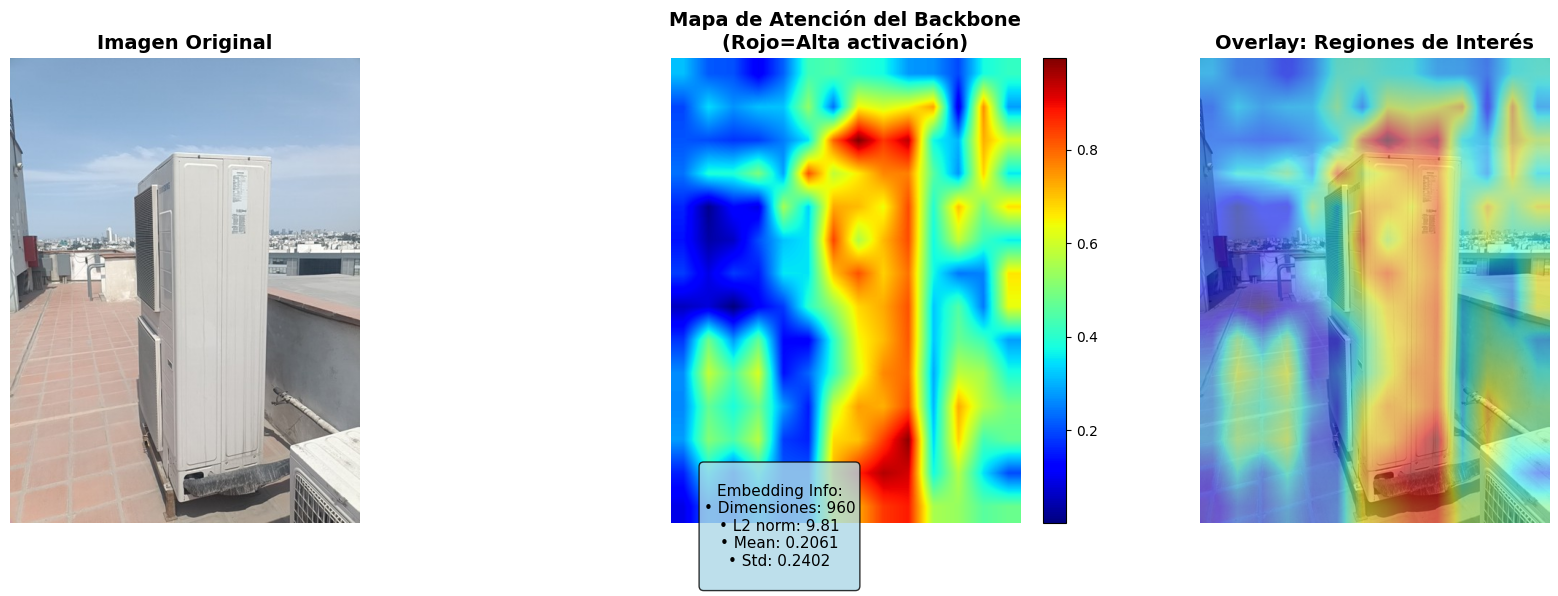

✓ Mapa de atención visualizado!

2. Análisis del embedding:
   • Shape: (960,)
   • Dtype: float32
   • Min value: -0.2365
   • Max value: 1.2228
   • Mean: 0.2061
   • Std: 0.2402
   • L2 norm: 9.8070

3. Distribución del embedding:


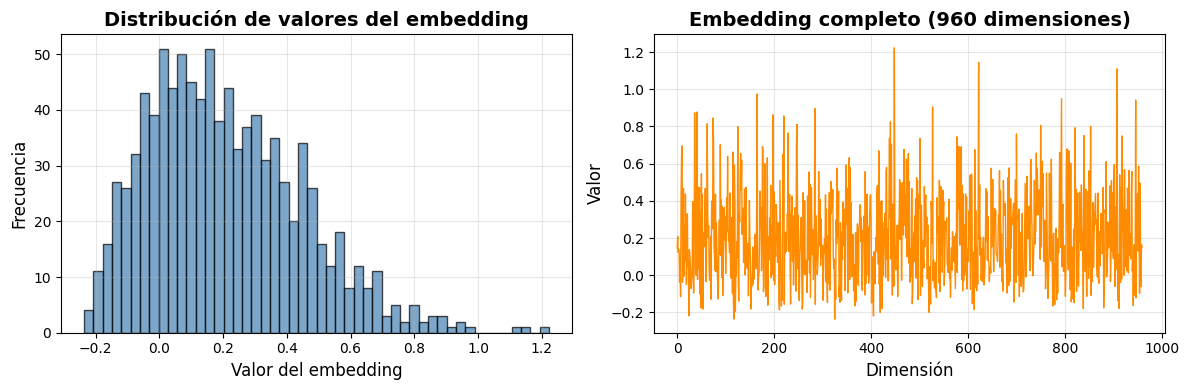


✓ Función funcionando correctamente!
✓ Embeddings listos para usar en comparaciones o búsquedas
✓ Mapa de atención muestra las regiones importantes del backbone


In [6]:
# Probar la función con una imagen de ejemplo
print("="*70)
print("PROBANDO LA FUNCIÓN CON VISUALIZACIÓN DE ATENCIÓN")
print("="*70)

# Usar imagen de ejemplo
test_image = "assets/vrf/snapshot_5.jpg"

print("\n1. Extrayendo embeddings con backbone entrenado...")
print("   (con visualización de mapa de atención)")
embeddings_trained = get_embeddings_from_image(
    image_path=test_image,
    model_path='backbone_segmentation_trained_v5.pth',
    device='cuda',
    show_attention=True  # ¡Mostrar mapa de atención!
)

print(f"\n2. Análisis del embedding:")
print(f"   • Shape: {embeddings_trained.shape}")
print(f"   • Dtype: {embeddings_trained.dtype}")
print(f"   • Min value: {embeddings_trained.min():.4f}")
print(f"   • Max value: {embeddings_trained.max():.4f}")
print(f"   • Mean: {embeddings_trained.mean():.4f}")
print(f"   • Std: {embeddings_trained.std():.4f}")
print(f"   • L2 norm: {np.linalg.norm(embeddings_trained):.4f}")

# Visualizar distribución del embedding
print("\n3. Distribución del embedding:")
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(embeddings_trained, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Valor del embedding', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución de valores del embedding', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(embeddings_trained, linewidth=1, color='darkorange')
plt.xlabel('Dimensión', fontsize=12)
plt.ylabel('Valor', fontsize=12)
plt.title(f'Embedding completo ({len(embeddings_trained)} dimensiones)', 
            fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("✓ Función funcionando correctamente!")
print("✓ Embeddings listos para usar en comparaciones o búsquedas")
print("✓ Mapa de atención muestra las regiones importantes del backbone")
print("="*70)
    